In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Load CIFAR-10 data
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Training images shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing images shape:", X_test.shape)
print("Testing labels shape:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1124s 7us/step
Training images shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing images shape: (10000, 32, 32, 3)
Testing labels shape: (10000, 1)


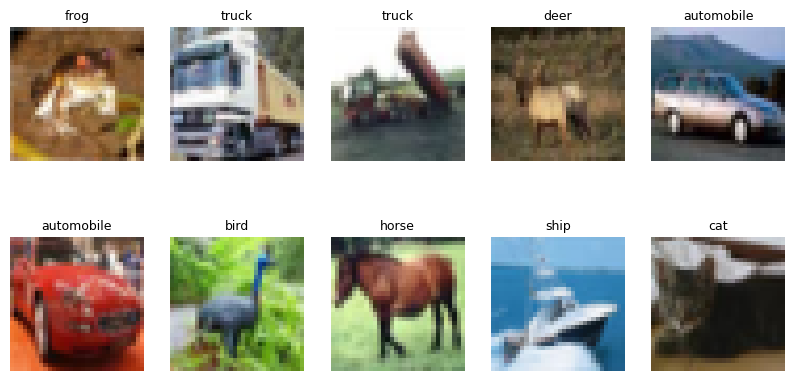

In [ ]:
# Define the text labels for CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Plotting the first 10 items
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])  # No cmap="gray" needed since it's a color image
    plt.title(class_names[y_train[i].flatten()[0]], fontsize=9)
    plt.axis("off")
plt.show()

In [ ]:
# --- Preprocessing ---
# Normalize pixel values to be between 0 and 1
x_train = X_train / 255.0
x_test = X_test / 255.0

# One-hot encode targets
Y_train = to_categorical(y_train, 10)
Y_test = to_categorical(y_test, 10)

# --- Build CNN Model ---
model = Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)), # Updated shape for 3-channel color images

    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation="relu"),    # Increased filters slightly for complex color patterns
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

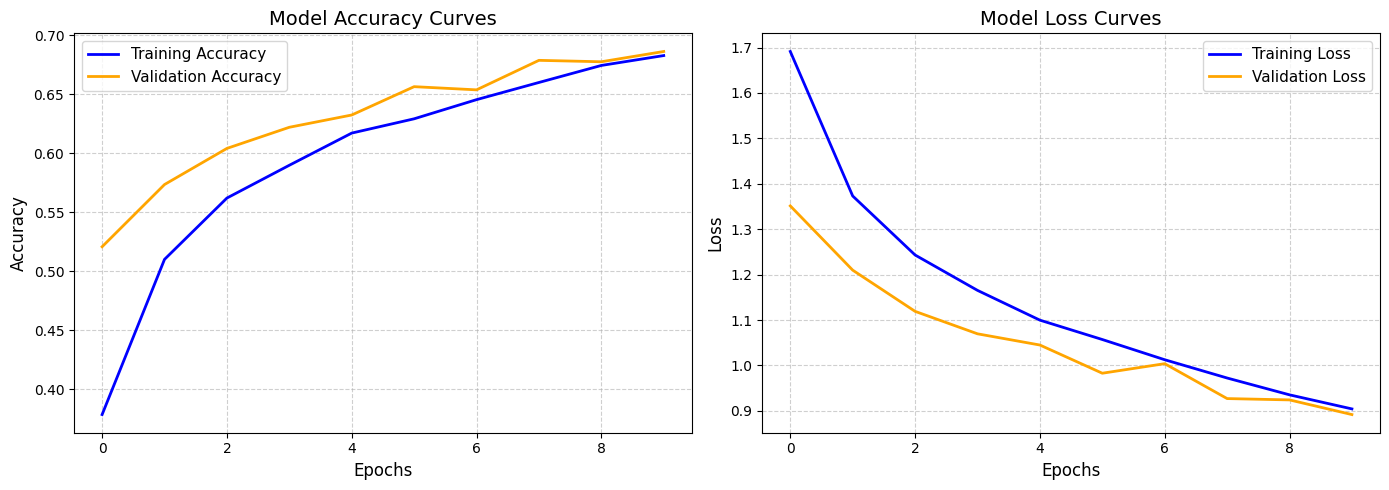

In [ ]:
# --- Plot Accuracy and Loss Curves ---
plt.figure(figsize=(14, 5))

# 1. Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy Curves', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# 2. Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('Model Loss Curves', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# --- Train ---
history = model.fit(
    x_train, Y_train,
    epochs=10,
    batch_size=64,                            # Bumped to 64 for faster training on CIFAR
    validation_split=0.2
)

# --- Evaluate ---
test_loss, test_accuracy = model.evaluate(x_test, Y_test)
print(f"\nTest Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 92ms/step - accuracy: 0.3787 - loss: 1.6914 - val_accuracy: 0.5209 - val_loss: 1.3514
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.5102 - loss: 1.3732 - val_accuracy: 0.5736 - val_loss: 1.2099
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - accuracy: 0.5622 - loss: 1.2432 - val_accuracy: 0.6042 - val_loss: 1.1192
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 86ms/step - accuracy: 0.5899 - loss: 1.1654 - val_accuracy: 0.6221 - val_loss: 1.0697
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 86ms/step - accuracy: 0.6172 - loss: 1.0998 - val_accuracy: 0.6325 - val_loss: 1.0450
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 89ms/step - accuracy: 0.6293 - loss: 1.0571 - val_accuracy: 0.6565 - val_loss: 0.9829
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 89ms/step - accuracy: 0.6455 - loss: 1.0126 - val_accuracy: 0.6538 - val_loss: 1.0040
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 85ms/step - accuracy: 0.6600 - loss: 0.9724 - 

Saving download (1).jpg to download (1).jpg


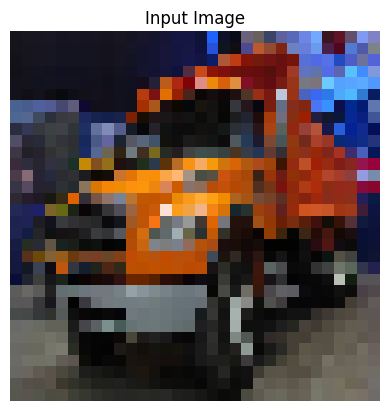

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
Predicted Item: truck
Confidence Score: 98.08 %


In [ ]:
from google.colab import files
import cv2

# 1. Trigger file upload
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# 2. Read and preprocess color image
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert from BGR (OpenCV default) to RGB
img = cv2.resize(img, (32, 32))             # Resize to CIFAR-10 dimensions

# Normalize
img_normalized = img / 255.0

# Display the processed image
plt.imshow(img_normalized)
plt.title("Input Image")
plt.axis('off')
plt.show()

# Reshape for the CNN structure (1 sample, 32x32 size, 3 color channels)
img_input = img_normalized.reshape(1, 32, 32, 3)

# 3. Predict
prediction = model.predict(img_input)
predicted_class_idx = np.argmax(prediction)

print(f"Predicted Item: {class_names[predicted_class_idx]}")
print(f"Confidence Score: {np.max(prediction) * 100:.2f} %")